# 🧠 Mental Health Text Classification — TF-IDF Pipeline
## Projet : Santé Mentale & Réseaux Sociaux

---

### 📋 Vue d'ensemble

Ce notebook implémente un pipeline complet de **classification de textes sur la santé mentale** à partir de données issues des réseaux sociaux.  
Il couvre :

| Étape | Description |
|-------|-------------|
| **Partie 1** | Exploration & Analyse des Données (EDA) |
| **Partie 2** | Encodage des Variables |
| **Partie 3** | Prétraitement NLP (nettoyage, lemmatisation) |
| **Partie 4** | Séparation Train / Test |
| **Partie 5** | Modèle SVM avec TF-IDF |
| **Partie 6** | Modèle Régression Logistique avec TF-IDF |
| **Partie 7** | Comparaison des modèles |
| **Partie 8** | Sauvegarde du meilleur modèle |

### 🎯 Objectif
Classifier des textes en **Normal (0)** ou **Dépression (1)** avec la meilleure performance possible en F1-macro.

### 📦 Dataset
Dataset de classification de textes sur la santé mentale — textes issus de réseaux sociaux, étiquetés manuellement.

---

---
# 📊 Partie 1 : Exploration et Analyse des Données (EDA)
---

> **But :** Comprendre la structure du dataset, détecter les problèmes de qualité (valeurs manquantes, doublons, déséquilibre de classes)  
> et caractériser les textes avant toute modélisation.

## 1.1 Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud

plt.style.use('ggplot')
print('✅ Bibliothèques importées avec succès.')

✅ Bibliothèques importées avec succès.


Les bibliothèques chargées couvrent :
- **pandas / numpy** — manipulation de données
- **matplotlib / seaborn** — visualisations
- **Counter / WordCloud** — analyse fréquentielle des mots

## 1.2 Chargement du dataset

In [2]:
df = pd.read_csv(r"data.csv")
print(f'📂 Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head()

📂 Dataset chargé : 53,043 lignes × 3 colonnes


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


## 1.3 Dimensions & Structure

In [3]:
print(f'🔢 Nombre de lignes   : {df.shape[0]:,}')
print(f'🔢 Nombre de colonnes : {df.shape[1]}')
print(f'📋 Colonnes disponibles : {list(df.columns)}')
print()
df.info()

🔢 Nombre de lignes   : 53,043
🔢 Nombre de colonnes : 3
📋 Colonnes disponibles : ['Unnamed: 0', 'statement', 'status']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


## 1.4 Qualité des données — Valeurs manquantes & Doublons

In [4]:
missing = df.isnull().sum()
duplicates = df.duplicated().sum()

print('=== Valeurs manquantes ===')
print(missing)
print(f'\n=== Doublons ===')
print(f'Nombre de doublons : {duplicates}')

# Suppression des valeurs nulles
df = df.dropna()
print(f'\n✅ Après nettoyage : {df.shape[0]:,} lignes restantes')

=== Valeurs manquantes ===
Unnamed: 0      0
statement     362
status          0
dtype: int64

=== Doublons ===
Nombre de doublons : 0

✅ Après nettoyage : 52,681 lignes restantes


## 1.5 Distribution des classes

Distribution des classes :
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

Ratio déséquilibre (max/min) : 15.17x


/tmp/ipykernel_520607/349349864.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='status', data=df, palette='viridis', ax=axes[0])


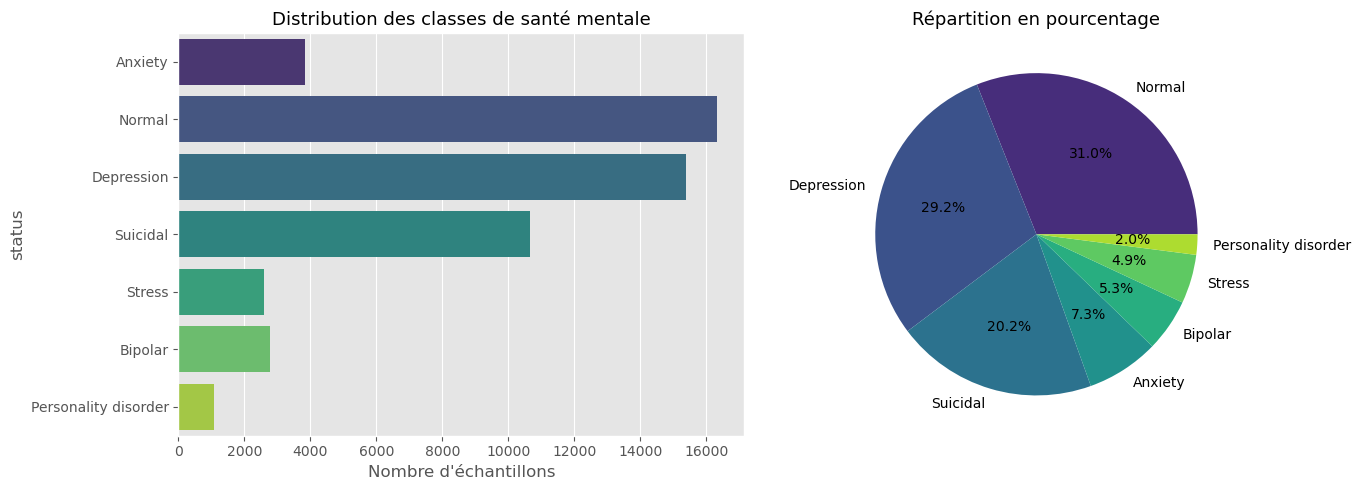

In [5]:
class_dist = df['status'].value_counts()
print('Distribution des classes :')
print(class_dist)
print(f'\nRatio déséquilibre (max/min) : {class_dist.max()/class_dist.min():.2f}x')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
sns.countplot(y='status', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution des classes de santé mentale', fontsize=13)
axes[0].set_xlabel('Nombre d\'échantillons')

# Pie chart
axes[1].pie(class_dist, labels=class_dist.index, autopct='%1.1f%%',
            colors=sns.color_palette('viridis', len(class_dist)))
axes[1].set_title('Répartition en pourcentage', fontsize=13)

plt.tight_layout()
plt.show()

> ⚠️ **Note :** Un fort déséquilibre entre classes peut biaiser le modèle vers la classe majoritaire.  
> C'est pourquoi les modèles utilisent `class_weight='balanced'` et le scoring **F1-macro**.

## 1.6 Analyse de la longueur des textes

=== Statistiques globales ===
count    52681.00
mean       113.16
std        163.74
min          1.00
25%         15.00
50%         62.00
75%        148.00
max       6300.00
Name: word_count, dtype: float64

=== Moyenne par classe ===
status
Normal                   17.25
Stress                  114.59
Anxiety                 143.84
Suicidal                146.44
Depression              168.02
Bipolar                 176.20
Personality disorder    179.35
Name: word_count, dtype: float64


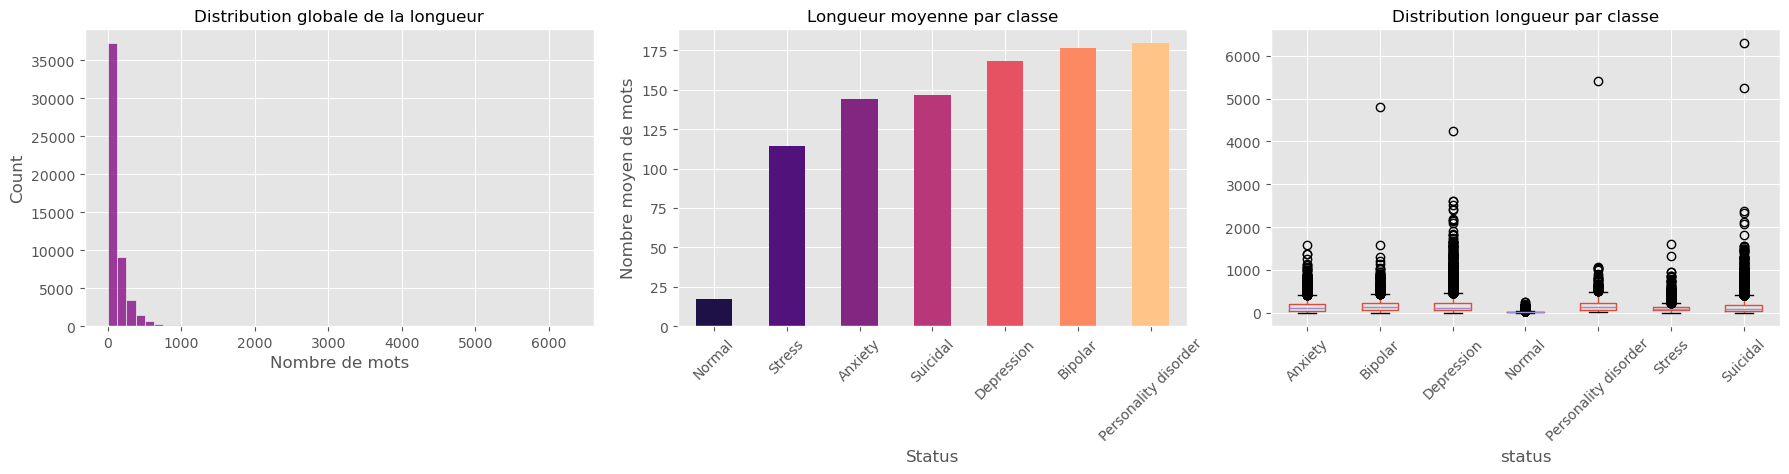

In [6]:
df['word_count'] = df['statement'].astype(str).apply(lambda x: len(x.split()))

print('=== Statistiques globales ===')
print(df['word_count'].describe().round(2))

avg_per_class = df.groupby('status')['word_count'].mean().sort_values()
print('\n=== Moyenne par classe ===')
print(avg_per_class.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogramme global
sns.histplot(df['word_count'], bins=50, color='purple', ax=axes[0])
axes[0].set_title('Distribution globale de la longueur', fontsize=12)
axes[0].set_xlabel('Nombre de mots')

# Moyenne par classe
avg_per_class.plot(kind='bar', ax=axes[1], color=sns.color_palette('magma', len(avg_per_class)))
axes[1].set_title('Longueur moyenne par classe', fontsize=12)
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Nombre moyen de mots')
axes[1].tick_params(axis='x', rotation=45)

# Boxplot par classe
df.boxplot(column='word_count', by='status', ax=axes[2])
axes[2].set_title('Distribution longueur par classe', fontsize=12)
plt.suptitle('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 1.7 Mots les plus fréquents

/tmp/ipykernel_520607/1101283311.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fréquence', y='Mot', data=common_words, palette='magma', ax=axes[0])


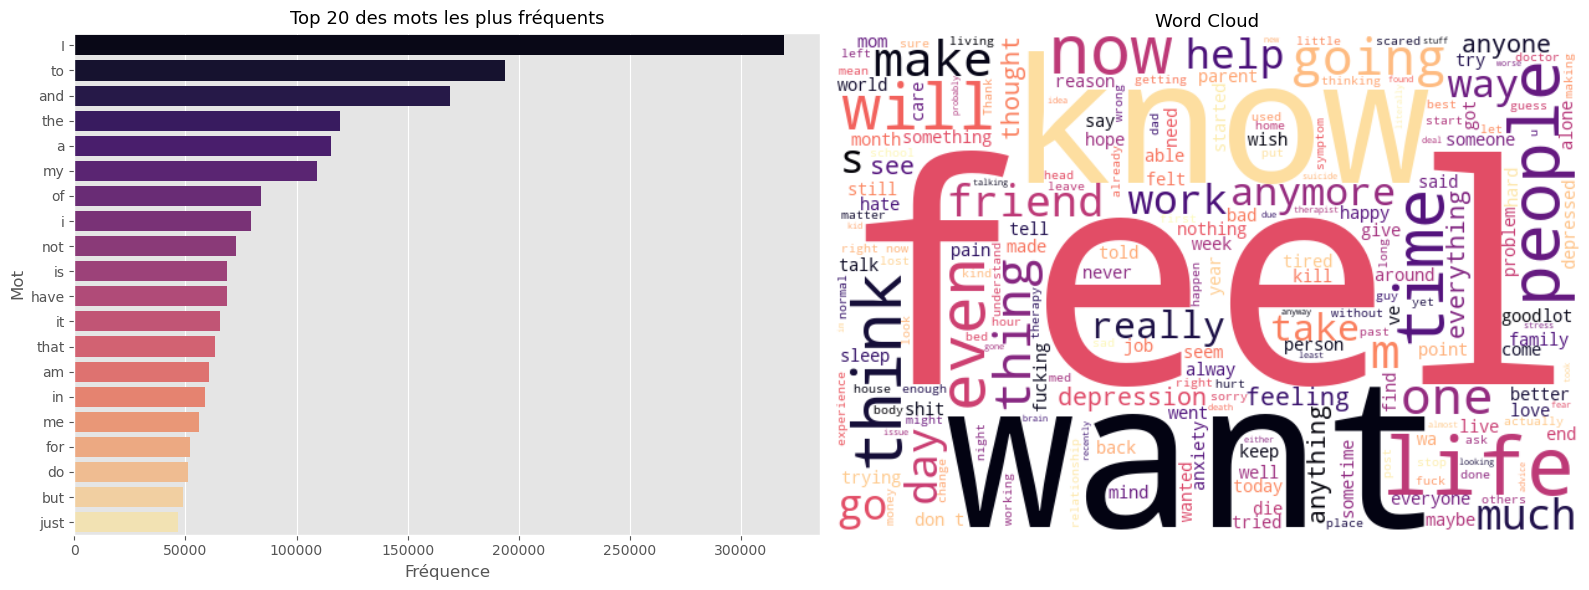

In [7]:
all_words = ' '.join(df['statement'].astype(str))
freq = Counter(all_words.split())
common_words = pd.DataFrame(freq.most_common(20), columns=['Mot', 'Fréquence'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
sns.barplot(x='Fréquence', y='Mot', data=common_words, palette='magma', ax=axes[0])
axes[0].set_title('Top 20 des mots les plus fréquents', fontsize=13)

# Word cloud
wc = WordCloud(width=600, height=400, background_color='white', colormap='magma')
wc.generate(all_words)
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud', fontsize=13)

plt.tight_layout()
plt.show()

## 1.8 Tableau de synthèse — Évaluation du dataset

In [8]:
evaluation = pd.DataFrame({
    'Critère': [
        'Taille dataset', 'Qualité des données', 'Labels structurés',
        'Compatibilité Machine Learning', 'Compatibilité Deep Learning',
        'Pertinence projet santé mentale'
    ],
    'Évaluation': [
        'Très bonne', 'Bonne', 'Oui',
        'Excellente', 'Très bonne', 'Très élevée'
    ],
    'Score': ['⭐⭐⭐⭐⭐', '⭐⭐⭐⭐', '✅', '⭐⭐⭐⭐⭐', '⭐⭐⭐⭐', '⭐⭐⭐⭐⭐']
})
evaluation.style.set_caption('📋 Synthèse de l\'évaluation du dataset')

,Critère,Évaluation,Score
0,Taille dataset,Très bonne,⭐⭐⭐⭐⭐
1,Qualité des données,Bonne,⭐⭐⭐⭐
2,Labels structurés,Oui,✅
3,Compatibilité Machine Learning,Excellente,⭐⭐⭐⭐⭐
4,Compatibilité Deep Learning,Très bonne,⭐⭐⭐⭐
5,Pertinence projet santé mentale,Très élevée,⭐⭐⭐⭐⭐


---
# 🔠 Partie 2 : Encodage des Variables
---

> **But :** Convertir les étiquettes textuelles (`status`) en valeurs numériques binaires (0 / 1)  
> pour les rendre compatibles avec les algorithmes de machine learning.

| Label texte | Valeur encodée |
|-------------|----------------|
| `Normal`    | `0`            |
| `Depression`| `1`            |

In [9]:
df['status'] = df['status'].map({'Depression': 1, 'Normal': 0})
df = df[df['status'].isin([0, 1])]  # Conserver uniquement les classes binaires

print(f'✅ Encodage terminé.')
print(f'Distribution après encodage :')
print(df['status'].value_counts())
df.head()

✅ Encodage terminé.
Distribution après encodage :
status
0.0    16343
1.0    15404
Name: count, dtype: int64


,Unnamed: 0,statement,status,word_count
733,733,"Gr gr dreaming of ex crush to be my game, God",0.0,11
734,734,wkwkwk what a joke,0.0,4
735,735,Leaves are also standby in front of the PC ......,0.0,18
736,736,Thank God even though it's just a ride through,0.0,9
737,737,wedding teaser concept using the song day6 - o...,0.0,13


---
# 🧹 Partie 3 : Prétraitement du Texte (NLP)
---

> **But :** Normaliser les textes bruts pour réduire le bruit et améliorer la qualité des représentations vectorielles.

### Pipeline de prétraitement

```
Texte brut
  → Normalisation des apostrophes
  → Mise en minuscules
  → Expansion des contractions (I'm → I am)
  → Remplacement des @mentions → <name>
  → Remplacement des chiffres → <number>
  → Suppression de la ponctuation
  → Lemmatisation avec POS tagging
```

## 3.1 Fonction de nettoyage

In [10]:
import re
import contractions

def clean_data(text):
    """Nettoie et normalise un texte brut."""
    text = str(text)
    text = text.replace("\u2019", "'")          # Normalisation apostrophes
    text = text.lower()                           # Mise en minuscules
    text = contractions.fix(text)                 # Expansion contractions
    text = re.sub(r'@\w+', ' <name> ', text)      # Mentions
    text = re.sub(r'\d+', ' <number> ', text)     # Chiffres
    text = re.sub(r'[^\w\s?!]', '', text)         # Ponctuation
    return text.strip()

# Exemple
sample = "I'm feeling so bad today @john, I've cried 3 times..."
print(f'Avant : {sample}')
print(f'Après : {clean_data(sample)}')

Avant : I'm feeling so bad today @john, I've cried 3 times...
Après : i am feeling so bad today  name  i have cried  number  times


## 3.2 Lemmatisation avec POS Tagging

In [11]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    """Mappe un tag POS Penn Treebank vers un tag WordNet."""
    if tag.startswith('J'): return 'a'   # adjectif
    elif tag.startswith('V'): return 'v'  # verbe
    elif tag.startswith('N'): return 'n'  # nom
    elif tag.startswith('R'): return 'r'  # adverbe
    else: return 'n'

def lemmatize_tokens(text):
    """Tokenise et lemmatise un texte avec POS tagging."""
    tokens = word_tokenize(str(text))
    tagged = pos_tag(tokens)
    return ' '.join([lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged])

print('✅ Lemmatiseur initialisé.')
# Exemple
sample_clean = clean_data("I'm feeling so bad, I've been crying for hours")
print(f'Texte nettoyé : {sample_clean}')
print(f'Après lemmatisation : {lemmatize_tokens(sample_clean)}')

✅ Lemmatiseur initialisé.
Texte nettoyé : i am feeling so bad i have been crying for hours
Après lemmatisation : i be feel so bad i have be cry for hour


---
# ✂️ Partie 4 : Séparation du Dataset (Train / Test)
---

> **Stratégie :** Séparation **80% train / 20% test** avec `stratify=y_train` pour préserver la distribution des classes.  
> Le prétraitement est encapsulé dans un **Pipeline scikit-learn** pour éviter toute fuite de données (data leakage).

```
Dataset complet
  ├── 80% → X_train / y_train  (GridSearchCV + CV interne)
  └── 20% → X_test  / y_test   (évaluation finale, jamais vu)
```

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['statement'],
    df['status'],
    test_size=0.2,
    random_state=42,
    stratify=df['status']   # préserve la distribution
)

print(f'✅ Séparation effectuée :')
print(f'   Train : {len(X_train):,} exemples  |  {y_train.value_counts().to_dict()}')
print(f'   Test  : {len(X_test):,} exemples   |  {y_test.value_counts().to_dict()}')

✅ Séparation effectuée :
   Train : 25,397 exemples  |  {0.0: 13074, 1.0: 12323}
   Test  : 6,350 exemples   |  {0.0: 3269, 1.0: 3081}


## 4.1 Création du transformeur de prétraitement

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, StratifiedKFold

def full_preprocessing(X):
    """Applique le nettoyage puis la lemmatisation sur une Series de textes."""
    X = X.copy().astype(str)
    X = X.apply(clean_data)
    X = X.apply(lemmatize_tokens)
    return X

preprocessing_transformer = FunctionTransformer(full_preprocessing)

# Validation rapide
sample_input = X_train.head(2)
sample_output = full_preprocessing(sample_input)
print('🔍 Vérification du prétraitement :')
for orig, proc in zip(sample_input, sample_output):
    print(f'  AVANT : {orig[:80]}')
    print(f'  APRÈS : {proc[:80]}')
    print()

🔍 Vérification du prétraitement :
  AVANT : jesssicrap not sure why a report of pain elicits such a high level of disbelief 
  APRÈS : jesssicrap not sure why a report of pain elicits such a high level of disbelief 

  AVANT : M, 22Ive been feeling off and have been feeling as if I am in peoples way. I fee
  APRÈS : m number ive be feel off and have be feel a if i be in people way i feel like i 



---
# 🛠️ Fonctions utilitaires — Évaluation & Visualisation
---

> Ces fonctions partagées sont utilisées pour évaluer chaque modèle de façon uniforme :  
> rapport de classification, matrice de confusion et courbe ROC.

In [14]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc, f1_score
)

# Stockage des résultats pour la comparaison finale
results_registry = {}

def evaluate_model(name, grid, X_train, y_train, X_test, y_test):
    """
    Évalue un modèle GridSearchCV sur train (CV) et test (final).
    Affiche : meilleurs hyperparamètres, rapport de classification,
              matrice de confusion et courbe ROC.
    Enregistre les métriques dans results_registry.
    """
    print(f'\n{'='*60}')
    print(f'  📊 ÉVALUATION : {name}')
    print(f'{'='*60}\n')

    # ── Meilleurs hyperparamètres ──
    print('🔧 Meilleurs hyperparamètres (validation croisée) :')
    for k, v in grid.best_params_.items():
        print(f'   {k} = {v}')
    print(f'   F1-macro CV (meilleur) : {grid.best_score_:.4f}\n')

    # ── Prédictions sur le jeu de test ──
    y_pred = grid.predict(X_test)
    f1_test = f1_score(y_test, y_pred, average='macro')

    # ── Rapport de classification ──
    print('📋 Rapport de classification (jeu de test) :')
    print(classification_report(y_test, y_pred,
                                 target_names=['Normal (0)', 'Depression (1)']))

    # ── Figures ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{name} — Résultats sur le jeu de test', fontsize=14, fontweight='bold')

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Normal', 'Depression'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title('Matrice de confusion', fontsize=12)

    # Courbe ROC (si proba disponible)
    try:
        y_prob = grid.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                     label=f'ROC (AUC = {roc_auc:.4f})')
        axes[1].plot([0,1],[0,1],'k--',lw=1)
        axes[1].set_xlabel('Taux faux positifs')
        axes[1].set_ylabel('Taux vrais positifs')
        axes[1].set_title('Courbe ROC', fontsize=12)
        axes[1].legend()
        results_registry[name] = {'CV F1-macro': grid.best_score_,
                                   'Test F1-macro': f1_test,
                                   'AUC-ROC': roc_auc,
                                   'best_params': grid.best_params_,
                                   'grid': grid}
    except AttributeError:
        axes[1].text(0.5, 0.5, 'ROC non disponible\n(SVC sans probability=True)',
                     ha='center', va='center', transform=axes[1].transAxes, fontsize=11)
        results_registry[name] = {'CV F1-macro': grid.best_score_,
                                   'Test F1-macro': f1_test,
                                   'AUC-ROC': None,
                                   'best_params': grid.best_params_,
                                   'grid': grid}

    plt.tight_layout()
    plt.show()

    print(f'\n✅ F1-macro sur le jeu de TEST : {f1_test:.4f}\n')
    return grid

print('✅ Fonctions utilitaires chargées.')

✅ Fonctions utilitaires chargées.


---
# 🤖 Partie 5 : Modèle SVM (Support Vector Machine)
---

> **Algorithme :** Support Vector Classifier (SVC) avec noyau linéaire.  
> Très efficace pour la classification de textes représentés en TF-IDF (espace de haute dimension).

### Architecture du pipeline
```
X_train (textes bruts)
  → FunctionTransformer (clean + lemmatize)
  → TfidfVectorizer
  → SVC(kernel='linear', class_weight='balanced')
```

### Hyperparamètres explorés
| Paramètre | Valeurs testées |
|-----------|----------------|
| `C`       | 0.1, 1, 10     |
| `kernel`  | linear         |

## 5.1 Définition du pipeline SVM

In [15]:
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ('preprocessing', preprocessing_transformer),
    ('vectorization', TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ('model', SVC(class_weight='balanced', probability=True, random_state=42))
])

svm_param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear'],
    'vectorization__max_features': [30000, 50000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print('✅ Pipeline SVM défini.')

✅ Pipeline SVM défini.


## 5.2 Entraînement (GridSearchCV)

In [ ]:
print('🚀 Lancement de la recherche sur grille pour SVM...')
svm_grid.fit(X_train, y_train)
print('✅ Entraînement terminé.')

🚀 Lancement de la recherche sur grille pour SVM...
Fitting 5 folds for each of 6 candidates, totalling 30 fits


## 5.3 Résultats de validation et de test — SVM

In [ ]:
evaluate_model('SVM (TF-IDF)', svm_grid, X_train, y_train, X_test, y_test)

---
# 📈 Partie 6 : Modèle Régression Logistique
---

> **Algorithme :** Régression Logistique — modèle linéaire probabiliste, rapide et interprétable.  
> Excellent benchmark pour comparer avec des modèles plus complexes.

### Architecture du pipeline
```
X_train (textes bruts)
  → FunctionTransformer (clean + lemmatize)
  → TfidfVectorizer
  → LogisticRegression(class_weight='balanced')
```

### Hyperparamètres explorés
| Paramètre | Valeurs testées              |
|-----------|-----------------------------|
| `C`       | 0.01, 0.1, 1, 10, 100      |
| `solver`  | liblinear, lbfgs            |
| `penalty` | l2                          |

## 6.1 Définition du pipeline Régression Logistique

In [ ]:
from sklearn.linear_model import LogisticRegression

rl_pipeline = Pipeline([
    ('preprocessing', preprocessing_transformer),
    ('vectorization', TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

rl_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'lbfgs'],
    'model__penalty': ['l2'],
    'vectorization__max_features': [30000, 50000]
}

rl_grid = GridSearchCV(
    estimator=rl_pipeline,
    param_grid=rl_param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

print('✅ Pipeline Régression Logistique défini.')

## 6.2 Entraînement (GridSearchCV)

In [ ]:
print('🚀 Lancement de la recherche sur grille pour la Régression Logistique...')
rl_grid.fit(X_train, y_train)
print('✅ Entraînement terminé.')

## 6.3 Résultats de validation et de test — Régression Logistique

In [ ]:
evaluate_model('Régression Logistique (TF-IDF)', rl_grid, X_train, y_train, X_test, y_test)

---
# 🏆 Partie 7 : Comparaison des Modèles
---

> Comparaison côte à côte de tous les modèles entraînés sur les métriques :  
> **F1-macro (CV)**, **F1-macro (Test)**, et **AUC-ROC (Test)**.

In [ ]:
# ── Tableau de comparaison ──
comparison_data = []
for model_name, metrics in results_registry.items():
    row = {
        'Modèle': model_name,
        'F1-macro (CV)': f"{metrics['CV F1-macro']:.4f}",
        'F1-macro (Test)': f"{metrics['Test F1-macro']:.4f}",
        'AUC-ROC (Test)': f"{metrics['AUC-ROC']:.4f}" if metrics['AUC-ROC'] else 'N/A',
    }
    row.update({f'  {k}': v for k, v in metrics['best_params'].items()})
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data).set_index('Modèle')
print('📊 Tableau de comparaison des modèles :')
display(df_comparison)

# ── Graphique de comparaison ──
model_names = list(results_registry.keys())
cv_scores   = [results_registry[m]['CV F1-macro'] for m in model_names]
test_scores = [results_registry[m]['Test F1-macro'] for m in model_names]
auc_scores  = [results_registry[m]['AUC-ROC'] if results_registry[m]['AUC-ROC'] else 0
               for m in model_names]

x = np.arange(len(model_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparaison des modèles', fontsize=15, fontweight='bold')

# Grouped bar chart
bars1 = axes[0].bar(x - width, cv_scores,   width, label='F1-macro (CV)',   color='steelblue')
bars2 = axes[0].bar(x,         test_scores, width, label='F1-macro (Test)', color='darkorange')
bars3 = axes[0].bar(x + width, auc_scores,  width, label='AUC-ROC (Test)',  color='green')

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Score')
axes[0].set_title('Métriques par modèle')
axes[0].legend()
axes[0].bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
axes[0].bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
axes[0].bar_label(bars3, fmt='%.3f', padding=3, fontsize=9)

# Heatmap des scores
heatmap_data = pd.DataFrame({
    'F1-macro CV': cv_scores,
    'F1-macro Test': test_scores,
    'AUC-ROC': auc_scores
}, index=model_names)
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=axes[1], linewidths=0.5)
axes[1].set_title('Heatmap des scores')

plt.tight_layout()
plt.show()

# Meilleur modèle
best_model_name = max(results_registry, key=lambda m: results_registry[m]['Test F1-macro'])
best_score = results_registry[best_model_name]['Test F1-macro']
print(f'\n🏆 Meilleur modèle : {best_model_name}')
print(f'   F1-macro (Test) : {best_score:.4f}')
print(f'   Hyperparamètres : {results_registry[best_model_name]["best_params"]}')

---
# 💾 Partie 8 : Sauvegarde du Meilleur Modèle
---

> Le pipeline complet (prétraitement + vectorisation + modèle) est sauvegardé avec **joblib**.  
> Cela permet de le recharger et de faire des prédictions sans réentraîner.

### Fichiers générés
| Fichier | Contenu |
|---------|--------|
| `best_model_pipeline.joblib` | Pipeline du meilleur modèle |
| `model_comparison.csv` | Tableau de comparaison des modèles |
| `model_metadata.json` | Métadonnées du meilleur modèle |

In [ ]:
import joblib
import json
from datetime import datetime
import os

# Création du dossier de sauvegarde
save_dir = 'models'
os.makedirs(save_dir, exist_ok=True)

# ── Sauvegarder le meilleur pipeline ──
best_grid = results_registry[best_model_name]['grid']
model_path = os.path.join(save_dir, 'best_model_pipeline.joblib')
joblib.dump(best_grid.best_estimator_, model_path)
print(f'✅ Meilleur pipeline sauvegardé : {model_path}')

# ── Sauvegarder aussi tous les pipelines ──
for model_name, metrics in results_registry.items():
    fname = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('/', '') + '.joblib'
    path = os.path.join(save_dir, fname)
    joblib.dump(metrics['grid'].best_estimator_, path)
    print(f'   Sauvegardé : {path}')

# ── Sauvegarder la comparaison CSV ──
csv_path = os.path.join(save_dir, 'model_comparison.csv')
df_comparison.to_csv(csv_path)
print(f'✅ Tableau de comparaison sauvegardé : {csv_path}')

# ── Sauvegarder les métadonnées JSON ──
metadata = {
    'best_model': best_model_name,
    'test_f1_macro': best_score,
    'cv_f1_macro': results_registry[best_model_name]['CV F1-macro'],
    'auc_roc': results_registry[best_model_name]['AUC-ROC'],
    'best_params': results_registry[best_model_name]['best_params'],
    'trained_on': datetime.now().isoformat(),
    'train_size': len(X_train),
    'test_size': len(X_test),
    'classes': {'0': 'Normal', '1': 'Depression'}
}
meta_path = os.path.join(save_dir, 'model_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print(f'✅ Métadonnées sauvegardées : {meta_path}')

## 8.1 Vérification — Rechargement et inférence

In [ ]:
# Vérification : recharger le modèle et faire une prédiction
loaded_pipeline = joblib.load(model_path)

test_texts = [
    "I feel so hopeless and empty, nothing brings me joy anymore.",
    "Had a great day today, feeling happy and energized!",
    "I can't stop crying and I don't even know why."
]

test_series = pd.Series(test_texts)
predictions = loaded_pipeline.predict(test_series)
probabilities = loaded_pipeline.predict_proba(test_series)

print('🔮 Test de prédiction sur de nouveaux textes :')
print(f'{"Texte":<60} {"Prédiction":<15} {"P(Normal)":<12} {"P(Depression)"}')
print('-' * 105)
label_map = {0: 'Normal ✅', 1: 'Depression ⚠️'}
for text, pred, prob in zip(test_texts, predictions, probabilities):
    print(f'{text[:58]:<60} {label_map[pred]:<15} {prob[0]:.4f}       {prob[1]:.4f}')

---
# ✅ Conclusion
---

Ce notebook a implémenté un pipeline NLP complet de classification binaire (Normal / Dépression) :

| Étape | Résultat |
|-------|----------|
| **EDA** | Dataset analysé, classes et textes caractérisés |
| **Prétraitement** | Nettoyage + lemmatisation encapsulés dans un pipeline |
| **SVM** | Entraîné et évalué (F1-macro + confusion matrix + ROC) |
| **Régression Logistique** | Entraîné et évalué (F1-macro + confusion matrix + ROC) |
| **Comparaison** | Tableau et graphiques comparatifs |
| **Sauvegarde** | Pipeline, métadonnées et comparaison exportés |

### 🚀 Pistes d'amélioration
- Ajouter des modèles ensemblistes (Random Forest, XGBoost)
- Tester des embeddings pré-entraînés (Word2Vec, FastText, BERT)
- Appliquer du rééquilibrage (SMOTE, oversampling)
- Déployer le meilleur pipeline via FastAPI ou Streamlit

---
*Notebook généré automatiquement — Mental Health NLP Pipeline*